In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder


## Loading Data

In [2]:
data = pd.read_csv('full_weaving_dataset.csv')

In [3]:
data.head()

,ID,Month,Construction,Req_Finish_Fabrics,Fabric_Allowance,Rec_Beam_length(yds),Shrink_allow,act_shrink%,Previous_pdn,Req_grey_fabric,Req_beam_length(yds),Total_pdn_m/c,Rej_and_cut_Piece,Total_pdn_per_order,warp_count,weft_count,epi,ppi
0,12207-8,January,40+40/2/40/110x80,31300,6.0,5752.336,12.5,12.26173158,5047,33297.87234,34797.6511,5047.0,0,0,double,80,110,80
1,12207-8,January,40+40/2/40/110x80,31300,6.0,5883.568,12.5,64.12041129,1952,33297.87234,34797.6511,2111.0,0,0,double,80,110,80
2,12207-8,January,40+40/2/40/110x80,31300,6.0,3094.888,12.5,24.13295732,2207,33297.87234,34797.6511,2348.0,0,0,double,80,110,80
3,12207-8,January,40+40/2/40/110x80,31300,6.0,5894.504,12.5,14.734132,5026,33297.87234,34797.6511,5026.0,0,0,double,80,110,80
4,12207-8,January,40+40/2/40/110x80,31300,6.0,5850.760,12.5,21.46319453,4391,33297.87234,34797.6511,4595.0,0,0,double,80,110,80


## Data Cleaning

#### Missing Value Handling

In [4]:
data.isnull().sum()

ID                          0
Month                       0
Construction                0
Req_Finish_Fabrics          0
Fabric_Allowance            0
Rec_Beam_length(yds)        0
Shrink_allow                0
act_shrink%                 0
Previous_pdn            13637
Req_grey_fabric             0
Req_beam_length(yds)        0
Total_pdn_m/c           13630
Rej_and_cut_Piece           0
Total_pdn_per_order         0
warp_count                  0
weft_count                  0
epi                         0
ppi                         0
dtype: int64

#### Removing the null values

In [5]:
data= data.dropna()

In [6]:
data.isnull().sum()

ID                      0
Month                   0
Construction            0
Req_Finish_Fabrics      0
Fabric_Allowance        0
Rec_Beam_length(yds)    0
Shrink_allow            0
act_shrink%             0
Previous_pdn            0
Req_grey_fabric         0
Req_beam_length(yds)    0
Total_pdn_m/c           0
Rej_and_cut_Piece       0
Total_pdn_per_order     0
warp_count              0
weft_count              0
epi                     0
ppi                     0
dtype: int64

#### Duplicate Value Handling

In [7]:
data.duplicated().sum()

np.int64(62648)

#### Removing the Duplicate Values

In [8]:
data = data.drop_duplicates()

In [9]:
data.duplicated().sum()

np.int64(0)

## Statistical Analysis

In [10]:
data.describe()

,Req_Finish_Fabrics,Fabric_Allowance,Rec_Beam_length(yds),Shrink_allow,Req_grey_fabric,Req_beam_length(yds),Total_pdn_m/c,Rej_and_cut_Piece,Total_pdn_per_order,weft_count,epi,ppi
count,44862.000000,44862.000000,44862.000000,44862.000000,44862.000000,44862.000000,4.486200e+04,44862.000000,44862.000000,44862.000000,44862.000000,44862.000000
mean,28172.417436,7.768053,4830.320772,12.699934,30269.156852,31644.543423,5.823320e+03,30.959141,3241.926709,73.016138,117.324373,84.190272
std,40172.379782,2.232077,15252.866728,2.604037,43164.250649,45090.714194,5.682555e+04,299.489898,29402.108033,1134.883253,12.630247,8.840724
min,50.000000,5.000000,0.000000,6.000000,54.347826,56.473019,0.000000e+00,0.000000,0.000000,20.000000,30.000000,42.000000
25%,3000.000000,7.000000,2036.283200,10.200000,3271.537623,3439.871745,4.920000e+02,0.000000,0.000000,40.000000,110.000000,80.000000
50%,8885.000000,7.000000,2597.300000,13.500000,9452.127660,9860.470134,1.220000e+03,0.000000,0.000000,40.000000,120.000000,90.000000
75%,40085.000000,8.000000,3237.056000,14.200000,43102.150540,45048.674950,2.045000e+03,0.000000,0.000000,40.000000,120.000000,90.000000
max,172800.000000,44.000000,292116.964000,40.800000,192427.616900,211997.533200,1.878576e+06,11353.000000,924098.000000,40140.000000,170.000000,110.000000


## Checking the datatypes

In [11]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 44862 entries, 0 to 121137
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   ID                    44862 non-null  object 
 1   Month                 44862 non-null  object 
 2   Construction          44862 non-null  object 
 3   Req_Finish_Fabrics    44862 non-null  int64  
 4   Fabric_Allowance      44862 non-null  float64
 5   Rec_Beam_length(yds)  44862 non-null  float64
 6   Shrink_allow          44862 non-null  float64
 7   act_shrink%           44862 non-null  object 
 8   Previous_pdn          44862 non-null  object 
 9   Req_grey_fabric       44862 non-null  float64
 10  Req_beam_length(yds)  44862 non-null  float64
 11  Total_pdn_m/c         44862 non-null  float64
 12  Rej_and_cut_Piece     44862 non-null  int64  
 13  Total_pdn_per_order   44862 non-null  int64  
 14  warp_count            44862 non-null  object 
 15  weft_count            4

## Separating the numerical and categorical columns

In [12]:
numerical_features = data.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = data.select_dtypes(include=[object]).columns.tolist()
print("Numerical Features:", numerical_features)
print("Categorical Features:", categorical_features)

Numerical Features: ['Req_Finish_Fabrics', 'Fabric_Allowance', 'Rec_Beam_length(yds)', 'Shrink_allow', 'Req_grey_fabric', 'Req_beam_length(yds)', 'Total_pdn_m/c', 'Rej_and_cut_Piece', 'Total_pdn_per_order', 'weft_count', 'epi', 'ppi']
Categorical Features: ['ID', 'Month', 'Construction', 'act_shrink%', 'Previous_pdn', 'warp_count']


## Explorartory Data Analysis (EDA)

#### Numerical Columns

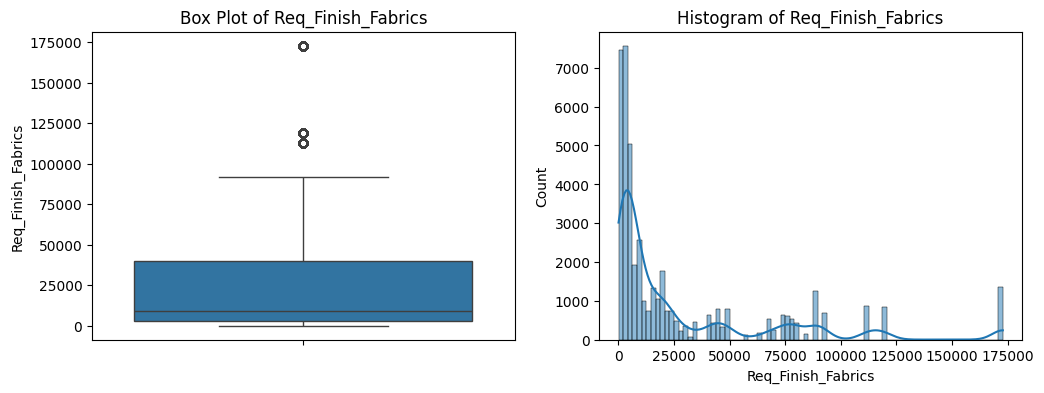

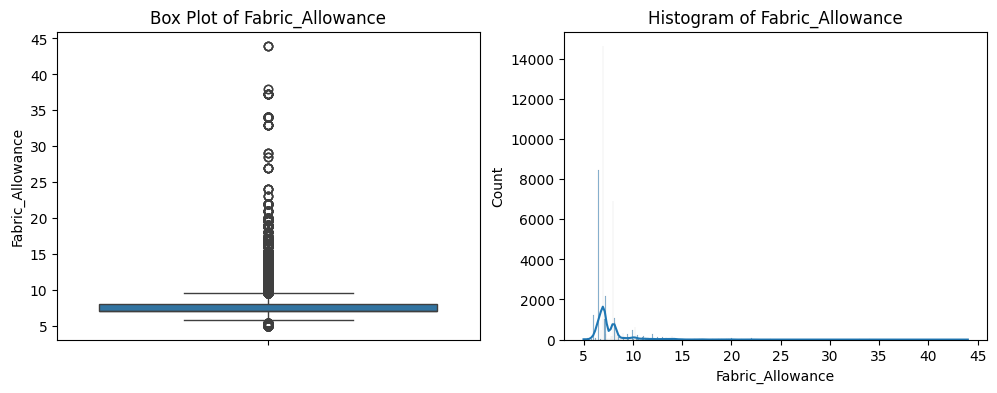

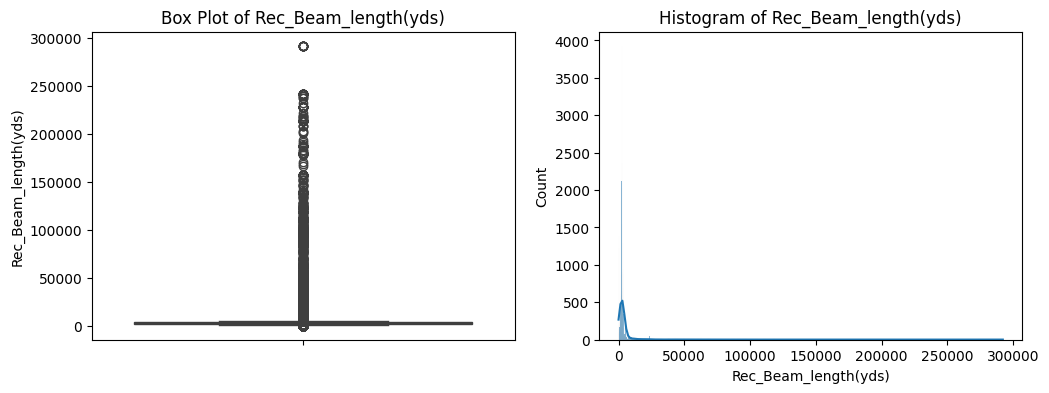

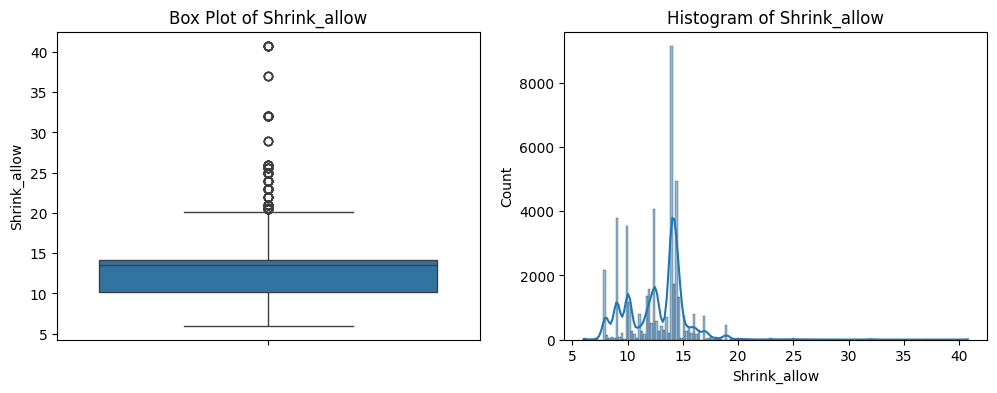

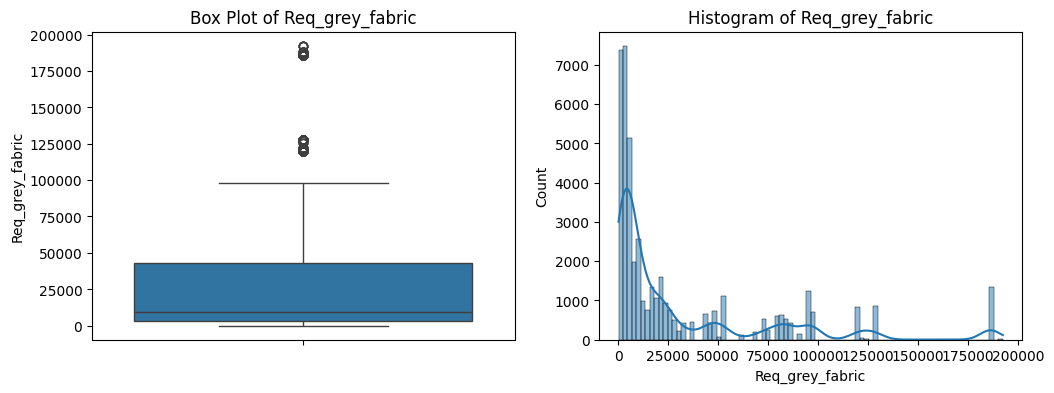

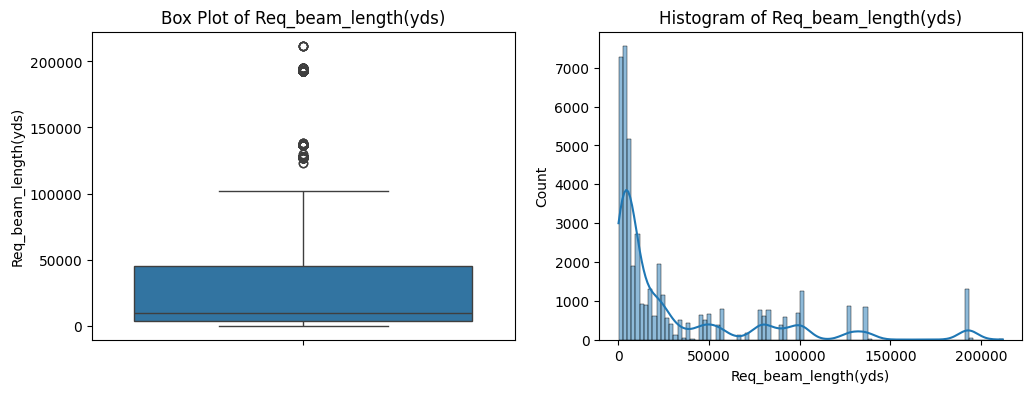

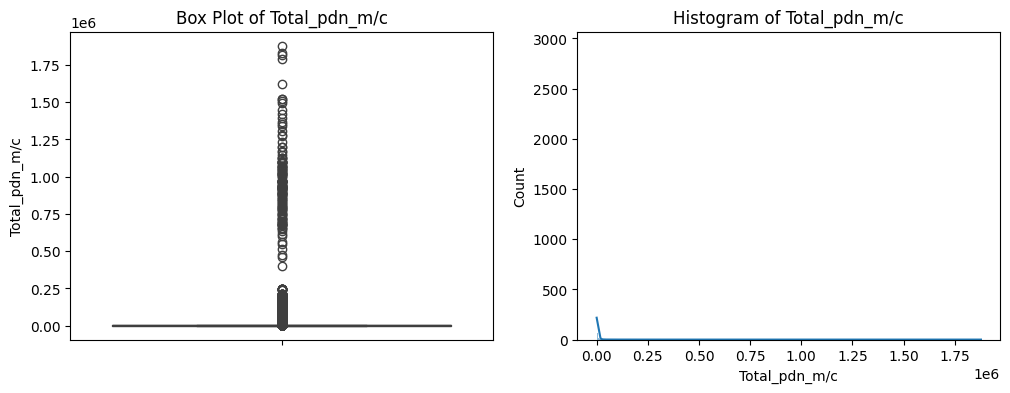

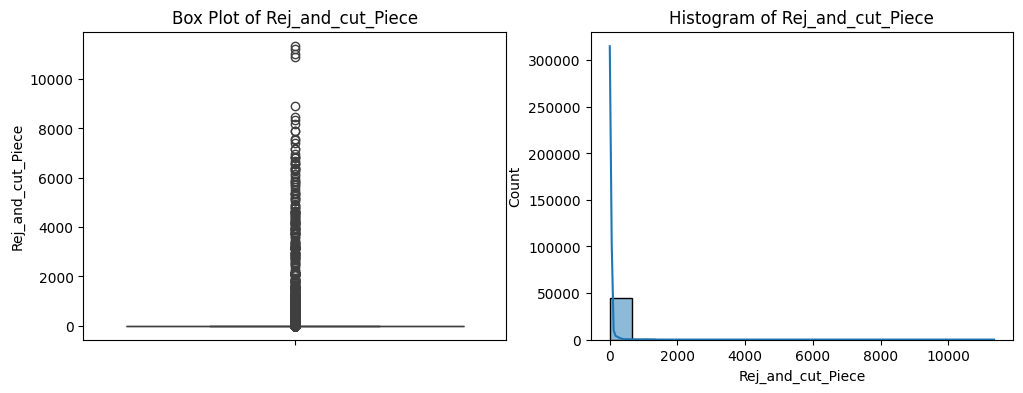

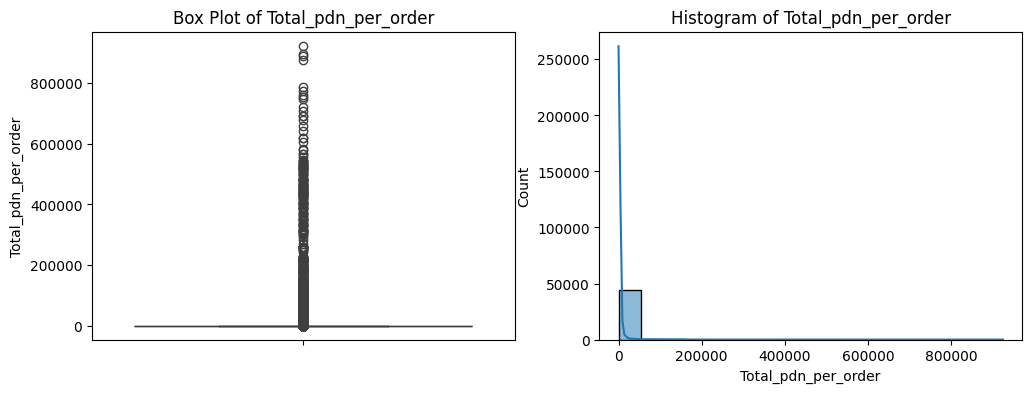

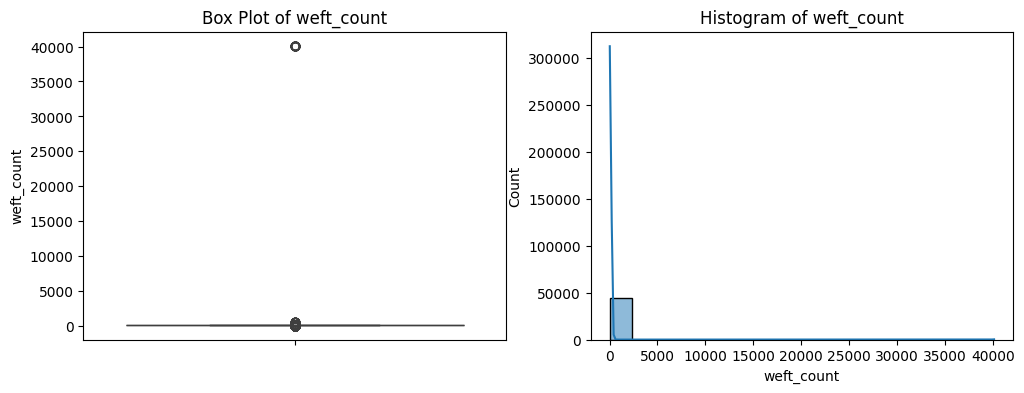

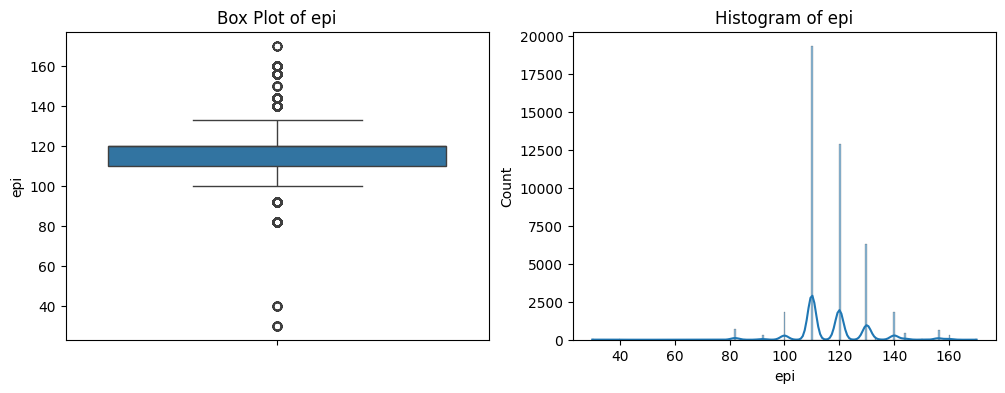

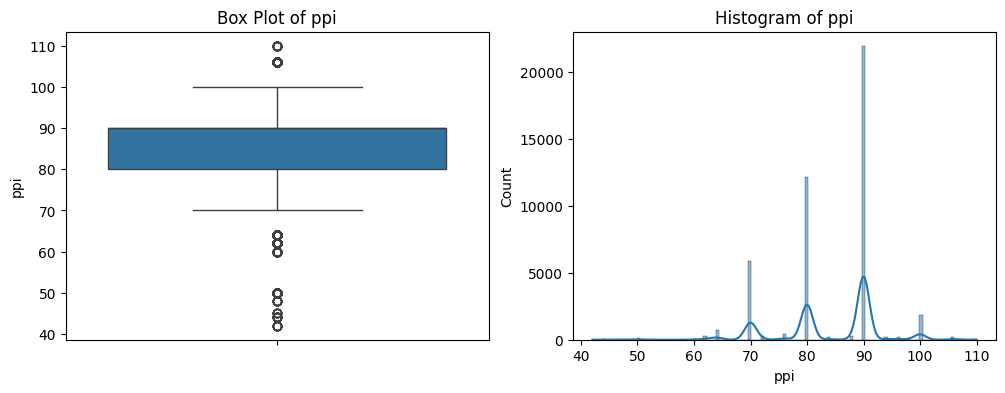

In [13]:
for c in numerical_features:
    fig,axes = plt.subplots(1,2,figsize=(12,4))
    
    # Box Plot
    sns.boxplot(data = data, y = c, ax=axes[0])
    axes[0].set_title(f'Box Plot of {c}')
    
    # histogram
    sns.histplot(data = data, x = c, ax=axes[1], kde=True)
    axes[1].set_title(f'Histogram of {c}')
    
    plt.show()

#### Categorical Columns

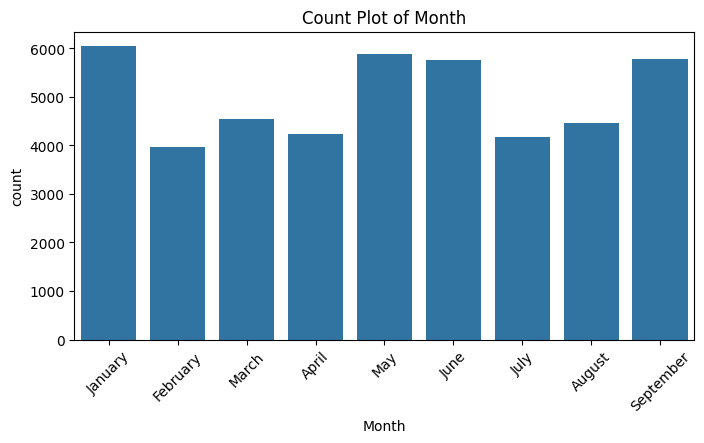

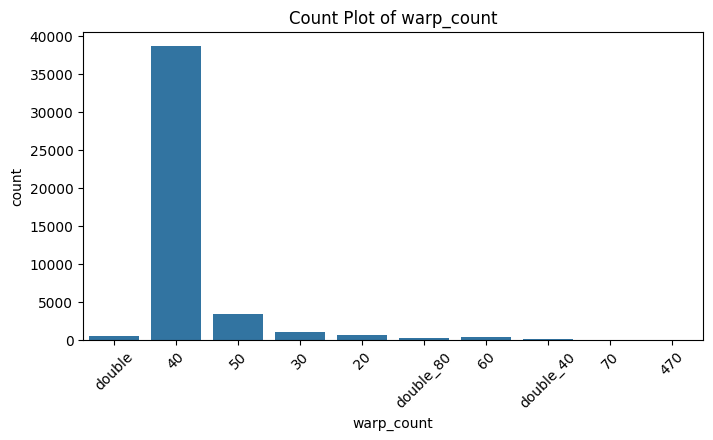

In [23]:
Categorical_cols =  [ 'Month',  'warp_count']
for c in Categorical_cols:
    plt.figure(figsize=(8,4))
    sns.countplot(data = data, x = c)
    plt.title(f'Count Plot of {c}')
    plt.xticks(rotation=45)
    plt.show()

#### Correlation checking

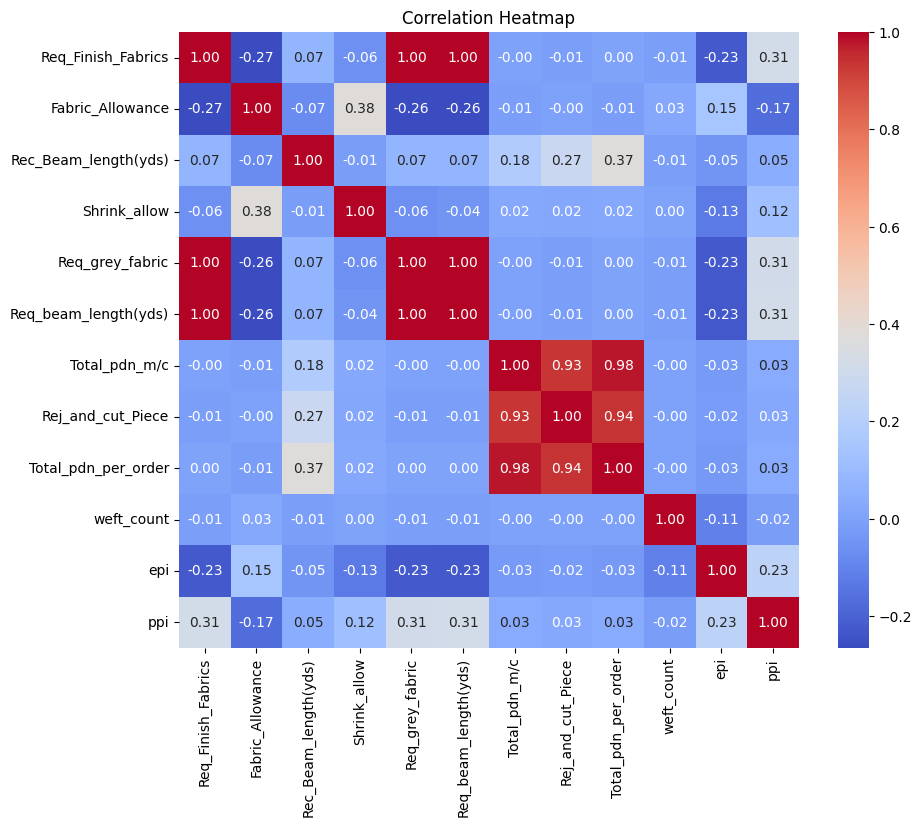

In [24]:
corr = data.corr(numeric_only=True)
plt.figure(figsize=(10,8))
sns.heatmap(corr,annot =True,fmt = '.2f',cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

#### Correlated Columns Handling

In [14]:
data = data.drop(columns=["Req_grey_fabric", "Req_beam_length(yds)",])


In [15]:
data = data.drop(columns=["ID", 'Total_pdn_per_order', 'Rej_and_cut_Piece'])

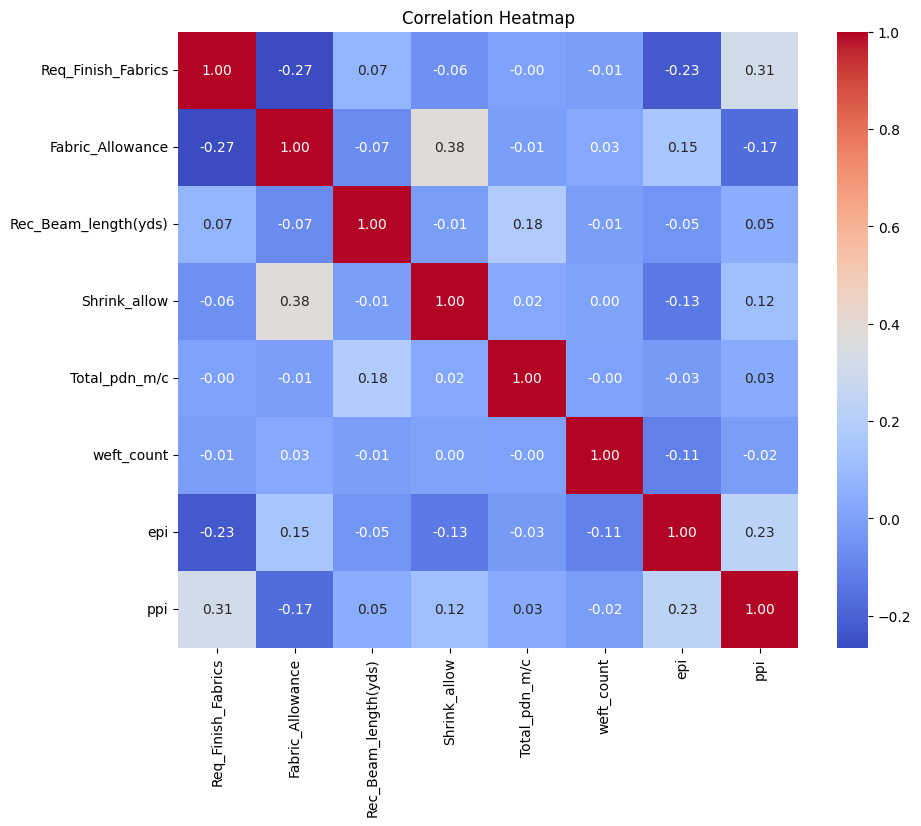

In [27]:
corr = data.corr(numeric_only=True)
plt.figure(figsize=(10,8))
sns.heatmap(corr,annot =True,fmt = '.2f',cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

## Outliers Removal by IQR Method

In [16]:

cols = [c for c in numerical_features if c in data.columns]

for c in cols:
    q1 = data[c].quantile(0.25)
    q3 = data[c].quantile(0.75)
    IQR = q3 - q1
    
    lower_bound = q1-1.5*IQR
    upper_bound = q3+ 1.5*IQR
    data = data[(data[c] >= lower_bound) & (data[c] <= upper_bound)]

## Separating the Dependent and Independent Variables

In [17]:
y = data['act_shrink%']
x = data.drop(columns=['act_shrink%'])

## Train Test Splitting

In [18]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [19]:
x.info()

<class 'pandas.core.frame.DataFrame'>
Index: 25563 entries, 8 to 121016
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Month                 25563 non-null  object 
 1   Construction          25563 non-null  object 
 2   Req_Finish_Fabrics    25563 non-null  int64  
 3   Fabric_Allowance      25563 non-null  float64
 4   Rec_Beam_length(yds)  25563 non-null  float64
 5   Shrink_allow          25563 non-null  float64
 6   Previous_pdn          25563 non-null  object 
 7   Total_pdn_m/c         25563 non-null  float64
 8   warp_count            25563 non-null  object 
 9   weft_count            25563 non-null  int64  
 10  epi                   25563 non-null  int64  
 11  ppi                   25563 non-null  int64  
dtypes: float64(4), int64(4), object(4)
memory usage: 2.5+ MB


## Encoding

In [ ]:
x_train["Previous_pdn"] = pd.to_numeric(x_train["Previous_pdn"], errors="coerce")   # text se number
x_train = x_train.drop(columns=["Construction"]) 
x_test["Previous_pdn"] = pd.to_numeric(x_test["Previous_pdn"], errors="coerce")   # text se number
x_test = x_test.drop(columns=["Construction"]) 

NameError: name 'X' is not defined